# Análisis ConnectaTel

Como **analista de datos**, tu objetivo es evaluar el **comportamiento de los clientes** de una empresa de telecomunicaciones en Latinoamérica, ConnectaTel. 

Trabajaremos con información registrada **hasta el año 2024**, lo cual permitirá analizar el comportamiento del negocio dentro de ese periodo.

Para ello trabajarás con tres datasets:  

- **plans.csv** → información de los planes actuales (precio, minutos incluidos, GB incluidos, costo por extra)  
- **users.csv** → información de los clientes (edad, ciudad, fecha de registro, plan, churn)  
- **usage.csv** → detalle del **uso real** de los servicios (llamadas y mensajes)  

Deberás **explorar**, **limpiar** y **analizar** estos datos para construir un **perfil estadístico** de los clientes, detectar **comportamientos atípicos** y crear **segmentos de clientes**.  

Este análisis te permitirá **identificar patrones de consumo**, **diseñar estrategias de retención** y **sugerir mejoras en los planes** ofrecidos por la empresa.

> 💡 Antes de empezar, recuerda pensar de forma **programática**: ¿qué pasos necesitas? ¿En qué orden? ¿Qué quieres medir y por qué?


--- 
## 🧩 Paso 1: Cargar y explorar

Antes de limpiar o combinar los datos, es necesario **familiarizarte con la estructura de los tres datasets**.  
En esta etapa, validarás que los archivos se carguen correctamente, conocerás sus columnas y tipos de datos, y detectarás posibles inconsistencias.

### 1.1 Carga de datos y vista rápida

**🎯 Objetivo:**  
Tener los **3 datasets listos en memoria**, entender su contenido y realizar una revisión preliminar.

**Instrucciones:**  
- Importa las librerías necesarias (por ejemplo `pandas`, `seaborn`, `matplotlib.pyplot`)
- Carga los archivos CSV usando `pd.read_csv()`:
  - **`/datasets/plans.csv`**  
  - **`/datasets/users_latam.csv`**  
  - **`/datasets/usage.csv`**  
- Guarda los DataFrames en las variables: `plans`, `users`, `usage`.  
- Muestra las primeras filas de cada DataFrame usando `.head()`.


In [1]:
# importar librerías
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

In [2]:
# cargar archivos
plans = pd.read_csv('/datasets/plans.csv')
users = pd.read_csv('/datasets/users_latam.csv') #completa el código
usage = pd.read_csv('/datasets/usage.csv')#completa el código

In [3]:
# mostrar las primeras 5 filas de plans
plans.head()

,plan_name,messages_included,gb_per_month,minutes_included,usd_monthly_pay,usd_per_gb,usd_per_message,usd_per_minute
0,Basico,100,5,100,12,1.2,0.08,0.10
1,Premium,500,20,600,25,1.0,0.05,0.07


In [4]:
# mostrar las primeras 5 filas de users
users.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date
0,10000,Carlos,Garcia,38,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN
1,10001,Mateo,Torres,53,?,2022-01-01 06:34:17.914478619,Basico,NaN
2,10002,Sofia,Ramirez,57,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN
3,10003,Mateo,Ramirez,69,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN
4,10004,Mateo,Torres,63,GDL,2022-01-02 02:17:11.657914478,Basico,NaN


In [5]:
# mostrar las primeras 5 filas de usage
usage.head()

,id,user_id,type,date,duration,length
0,1,10332,call,2024-01-01 00:00:00.000000000,0.09,NaN
1,2,11458,text,2024-01-01 00:06:30.969774244,NaN,39.0
2,3,11777,text,2024-01-01 00:13:01.939548488,NaN,36.0
3,4,10682,call,2024-01-01 00:19:32.909322733,1.53,NaN
4,5,12742,call,2024-01-01 00:26:03.879096977,4.84,NaN


**Tip:** Si no usas `print()` la tabla se vera mejor.

### 1.2 Exploración de la estructura de los datasets

**🎯 Objetivo:**  
Conocer la **estructura de cada dataset**, revisar cuántas filas y columnas tienen, identificar los **tipos de datos** de cada columna y detectar posibles **inconsistencias o valores nulos** antes de iniciar el análisis.

**Instrucciones:**  
- Revisa el **número de filas y columnas** de cada dataset usando `.shape`.  
- Usa `.info()` en cada DataFrame para obtener un **resumen completo** de columnas, tipos de datos y valores no nulos.  

In [6]:
# revisar el número de filas y columnas de cada dataset
print("plans", plans.shape)
print("users", users.shape)
print("usage", usage.shape)

plans (2, 8)
users (4000, 8)
usage (40000, 6)


In [7]:
# inspección de plans con .info()
plans.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2 entries, 0 to 1
Data columns (total 8 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   plan_name          2 non-null      object 
 1   messages_included  2 non-null      int64  
 2   gb_per_month       2 non-null      int64  
 3   minutes_included   2 non-null      int64  
 4   usd_monthly_pay    2 non-null      int64  
 5   usd_per_gb         2 non-null      float64
 6   usd_per_message    2 non-null      float64
 7   usd_per_minute     2 non-null      float64
dtypes: float64(3), int64(4), object(1)
memory usage: 256.0+ bytes


In [8]:
# inspección de users con .info()
users.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4000 entries, 0 to 3999
Data columns (total 8 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   user_id     4000 non-null   int64 
 1   first_name  4000 non-null   object
 2   last_name   4000 non-null   object
 3   age         4000 non-null   int64 
 4   city        3531 non-null   object
 5   reg_date    4000 non-null   object
 6   plan        4000 non-null   object
 7   churn_date  466 non-null    object
dtypes: int64(2), object(6)
memory usage: 250.1+ KB


In [9]:
# inspección de usage con .info()
usage.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 40000 entries, 0 to 39999
Data columns (total 6 columns):
 #   Column    Non-Null Count  Dtype  
---  ------    --------------  -----  
 0   id        40000 non-null  int64  
 1   user_id   40000 non-null  int64  
 2   type      40000 non-null  object 
 3   date      39950 non-null  object 
 4   duration  17924 non-null  float64
 5   length    22104 non-null  float64
dtypes: float64(2), int64(2), object(2)
memory usage: 1.8+ MB


---

## 🧩Paso 2: Identificación de problemas de calidad de datos

### 2.1 Revisión de valores nulos

**🎯 Objetivo:**  
Detectar la presencia y magnitud de valores faltantes para evaluar si afectan el análisis o requieren imputación/eliminación.

**Instrucciones:**  
- Cuenta valores nulos por columna para cada dataset.
- Calcula la proporción de nulos por columna para cada dataset.

El dataset `plans` solamente tiene 2 renglones y se puede observar que no tiene ausentes, por ello no necesita exploración adicional.

<br>
<details>
<summary>Haz clic para ver la pista</summary>
Usa `.isna().sum()` para contar valores nulos y usa `.isna().mean()` para calcular la proporción.

In [10]:
# cantidad de nulos para users
print(users.isna().sum())
print(users.isna().mean())

user_id          0
first_name       0
last_name        0
age              0
city           469
reg_date         0
plan             0
churn_date    3534
dtype: int64
user_id       0.00000
first_name    0.00000
last_name     0.00000
age           0.00000
city          0.11725
reg_date      0.00000
plan          0.00000
churn_date    0.88350
dtype: float64


In [11]:
# cantidad de nulos para usage
print(usage.isna().sum())
print(usage.isna().mean())

id              0
user_id         0
type            0
date           50
duration    22076
length      17896
dtype: int64
id          0.00000
user_id     0.00000
type        0.00000
date        0.00125
duration    0.55190
length      0.44740
dtype: float64


✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico al final del bloque. Incluye qué ves y que acción recomendarías para cada caso.

💡 **Nota:** Justifica tus decisiones brevemente (1 línea por caso).
* Hint:
 - Si una columna tiene **más del 80–90% de nulos**, normalmente se **ignora o elimina**.  
 - Si tiene **entre 5% y 30%**, generalmente se **investiga para imputar o dejar como nulos**.  
 - Si es **menor al 5%**, suele ser un caso simple de imputación o dejar como nulos. 
 
 ---

**Valores nulos**  
- ¿Qué columnas tienen valores faltantes y en qué proporción?  
- Indica qué harías: ¿imputar, eliminar, ignorar?

Dataset: users

Valores nulos detectados:
- city: 469 nulos (11.73%)
- churn_date: 3534 nulos (88.35%)
El resto de las columnas no presentan valores faltantes.

Diagnóstico y acción recomendada:

city (11.73%) → Está en el rango 5–30%.
Acción: Mantener la columna e investigar posibilidad de imputación o analizar si los nulos afectan segmentaciones geográficas.

churn_date (88.35%) → Más del 80% de nulos.
Acción: Los valores nulos en la columna churn_date no representan un problema ni un error en los datos; en realidad indican que el cliente sigue activo y no ha cancelado el servicio. Por esa razón no deben eliminarse, ya que perderíamos información valiosa. En lugar de borrarlos, es mejor convertir esta información en una variable más simple de 0 y 1, donde 1 signifique que el cliente se fue y 0 que sigue activo, para facilitar el análisis.

Dataset: usage

Valores nulos detectados:

date: 50 nulos (0.13%)

duration: 22,076 nulos (55.19%)

length: 17,896 nulos (44.74%)

id, user_id, type no presentan nulos.

Diagnóstico y acción recomendada:

date (0.13%) → Menor al 5%.
 Acción: Eliminar registros con fecha nula, impacto mínimo en el dataset.

duration (55.19%) → Alto porcentaje (>30%).
Acción: Investigar relación con type. Probablemente aplica solo a llamadas. No imputar sin analizar, podría ser nulo estructural.

length (44.74%) → Alto porcentaje (>30%).
Acción: Similar a duration, revisar si corresponde únicamente a mensajes. Si es nulo estructural según tipo, mantener; si no, evaluar eliminación.


### 2.2 Detección de valores inválidos y sentinels

🎯 **Objetivo:**  
Identificar sentinels: valores que no deberían estar en el dataset.

**Instrucciones:**
- Explora las columnas numéricas con **un resumen estadístico** y describe brevemente que encontraste.
- Explora las columnas categóricas **relevantes**, revisando sus valores únicos y describe brevemente que encontraste.


El dataset `plans` solamente tiene 2 renglones, por ello no necesita exploración adicional.

In [12]:
# explorar columnas numéricas de users
users.describe()

,user_id,age
count,4000.000000,4000.000000
mean,11999.500000,33.739750
std,1154.844867,123.232257
min,10000.000000,-999.000000
25%,10999.750000,32.000000
50%,11999.500000,47.000000
75%,12999.250000,63.000000
max,13999.000000,79.000000


- En la columna `user_id` no se observan valores extraños o inválidos. El mínimo es 10000 y el máximo 13999, lo que indica que los identificadores siguen una secuencia lógica y consistente. La media y los percentiles muestran una distribución uniforme, como se espera en una columna que funciona únicamente como identificador.

La desviación estándar es relativamente alta (1154), pero esto no representa un problema. Ocurre porque los valores están distribuidos a lo largo de un rango amplio de números consecutivos. Sin embargo, como user_id es solo un identificador y no una variable de análisis, esta variabilidad no tiene interpretación estadística relevante.

- La columna `age` tiene un valor mínimo de -999, lo cual no tiene sentido porque una edad no puede ser negativa. Esto indica que ese número se usó como un valor especial para representar un dato faltante. También se nota que la desviación estándar es muy alta, probablemente afectada por ese -999. Sin embargo, el resto de los valores (mediana 47, máximo 79) muestran que las edades reales están en un rango normal y lógico.

In [13]:
# explorar columnas numéricas de usage
usage.describe()

,id,user_id,duration,length
count,40000.00000,40000.000000,17924.000000,22104.000000
mean,20000.50000,12002.405975,5.202237,52.127398
std,11547.14972,1157.279564,6.842701,56.611183
min,1.00000,10000.000000,0.000000,0.000000
25%,10000.75000,10996.000000,1.437500,37.000000
50%,20000.50000,12013.000000,3.500000,50.000000
75%,30000.25000,13005.000000,6.990000,64.000000
max,40000.00000,13999.000000,120.000000,1490.000000


- La columna id tiene 40,000 registros completos, por lo que no presenta valores faltantes. Su media y mediana son exactamente iguales (20,000.5), lo que indica una distribución perfectamente centrada. El valor mínimo es 1 y el máximo es 40,000, mostrando que se trata de una secuencia continua y uniforme. La desviación estándar es alta, pero esto es completamente normal debido al amplio rango de valores. En general, esta columna funciona como un identificador único y no aporta información relevante para el análisis estadístico o de negocio, ya que solo sirve para identificar cada registro.
- En la columna user_id, us valores van de 10,000 a 13,999, lo que sugiere que identifica a distintos usuarios dentro de un rango específico. La media (≈12,002) y la mediana (12,013) son muy similares, lo que indica que la distribución está bastante equilibrada y sin un sesgo fuerte. La desviación estándar es moderada en relación con el rango, lo cual es consistente con una numeración distribuida entre varios usuarios. En general, al igual que id, esta columna funciona como un identificador
-En la columna usage, su media es aproximadamente 5.2, mientras que la mediana es 3.5, lo que muestra que la distribución está sesgada hacia la derecha. Esto significa que existen algunos valores altos que están elevando el promedio. La desviación estándar (≈6.84) es incluso mayor que la media, lo que confirma una alta dispersión y la posible presencia de valores extremos. El mínimo es 0 y el máximo llega hasta 120, lo que refuerza la idea de que hay registros inusualmente altos. En general, esta columna sí aporta información relevante para el análisis, pero requiere revisar los valores faltantes y posibles outliers antes de tomar decisiones.
-La columna lenght, u media es aproximadamente 52.1 y la mediana es 50, lo que indica que la distribución es relativamente equilibrada, aunque ligeramente sesgada hacia la derecha. Sin embargo, la desviación estándar es alta (≈56.6), lo que señala una gran dispersión en los datos. El valor mínimo es 0 y el máximo alcanza 1,490, lo que sugiere la presencia de valores extremadamente altos que podrían considerarse atípicos. En general, es una variable relevante para el análisis, pero conviene revisar tanto los valores faltantes como los posibles outliers

In [14]:
# explorar columnas categóricas de users
users['city'].value_counts()



Bogotá      808
CDMX        730
Medellín    616
GDL         450
Cali        424
MTY         407
?            96
Name: city, dtype: int64

In [15]:
users['plan'].value_counts()

Basico     2595
Premium    1405
Name: plan, dtype: int64

- La columna `city` muestra la distribución de usuarios por ciudad. Bogotá es la ciudad con mayor número de registros (808), seguida por CDMX (730) y Medellín (616). Esto indica que el mayor volumen de usuarios se concentra en estas tres ciudades, lo que podría representar los mercados más fuertes del negocio. Después aparecen GDL (450), Cali (424) y MTY (407), con una participación más moderada pero aún significativa. La distribución no está extremadamente desbalanceada, aunque sí se observa una mayor concentración en las primeras dos ciudades.

También aparece una categoría “?” con 96 registros, lo que sugiere valores desconocidos o mal registrados

- La columna `plan` muestra dos categorías: Basico con 2,595 usuarios y Premium con 1,405 usuarios. Esto indica que la mayoría de los usuarios tiene el plan básico, representando aproximadamente dos tercios del total, mientras que el plan premium tiene una menor participación

In [16]:
# explorar columna categórica de usage
usage['type'].value_counts() # completa el código


text    22092
call    17908
Name: type, dtype: int64

- La columna `type`  muestra dos categorías: text con 22,092 registros y call con 17,908. Esto indica que el uso de mensajes de texto es más frecuente que las llamadas dentro del dataset.


---
✍️ **Comentario**: Haz doble clic en este bloque y escribe tu diagnóstico. Incluye qué ves y que acción recomendarías para cada caso. 

**Valores inválidos o sentinels**  
- ¿En qué columnas encontraste valores inválidos o sentinels?
age / customer_age
Se encontró el valor -999, que no tiene sentido porque una edad no puede ser negativa. Claramente se utilizó como sentinel para representar un dato faltante.

city
Aparece la categoría "?" con 96 registros. No es un NaN, pero funciona como un valor inválido o mal registrado que representa información desconocida.
- ¿Qué acción tomarías?

En age / customer_age:
Reemplazaría -999 por NaN y posteriormente aplicaría una estrategia de imputación adecuada (preferiblemente la mediana si hay sesgo).

En city:
Reemplazaría "?" por NaN para tratarlo correctamente como dato faltante. Después evaluaría si conviene imputar (por ejemplo, con la moda) o mantenerlo como categoría “Desconocido”.

### 2.3 Revisión y estandarización de fechas

**🎯 Objetivo:**  
Asegurar que las columnas de fecha estén correctamente formateadas y detectar años fuera de rango que indiquen errores de captura.

**Instrucciones:**  
- Convierte las columnas de fecha a tipo fecha y asegurate de que el código sea a prueba de errores.  
- Revisa cuántas veces aparece cada año.
- Identifica fechas imposibles (ej. años futuros o negativos).

Toma en cuenta que tenemos datos registrados hasta el año 2024.

In [17]:
# Convertir a fecha la columna `reg_date` de users
users['reg_date'] = pd.to_datetime(users['reg_date']) # completa el código

In [18]:
# Convertir a fecha la columna `date` de usage
usage['date'] = pd.to_datetime(usage['date'], errors='coerce') # completa el código

In [19]:
# Revisar los años presentes en `reg_date` de users

años_presentes = sorted(users['reg_date'].dt.year.unique())
print("Años presentes en el dataset:", años_presentes)



Años presentes en el dataset: [2022, 2023, 2024, 2026]


In [20]:
(users['reg_date'].dt.year == 2026).sum()

40

In [21]:
registros_por_año = users['reg_date'].dt.year.value_counts().sort_index()
print("Usuarios registrados por año:")
print(registros_por_año)

Usuarios registrados por año:
2022    1314
2023    1316
2024    1330
2026      40
Name: reg_date, dtype: int64


En `reg_date`, se identifican los años presentes en el dataset: 2022, 2023, 2024 y 2026. Después, se muestra el número de usuarios registrados por año. Los registros se mantienen bastante estables entre 2022 (1314), 2023 (1316) y 2024 (1330), pero en 2026 solo aparecen 40 registros, lo que llama la atención y podría indicar datos incompletos, pruebas o un posible error en las fechas que valdría la pena revisar.

In [22]:
# Revisar los años presentes en `date` de usage
años_unicos = usage['date'].dt.year.unique()
print(f"Años presentes: {sorted(años_unicos)}")

Años presentes: [2024.0, nan]


En `date`,  se revisan los años presentes en la columna date del dataset de usage. Aparecen registros en 2022, 2023, 2024 y 2026, pero también se observa un valor NaN, lo que indica que existen fechas faltantes.

✍️ **Comentario**: escribe tu diagnóstico, e incluye **qué acción recomendarías** para cada caso:

**Fechas fuera de rango**  
- ¿Aparecen años imposibles? (años muy viejos o sin transcurrir al momento de guardar los datos)

  Sí aparecen fechas que llaman la atención. 2022, 2023 y 2024 se ven consistentes en volumen; 2026 también aparece, pero considerando que solo llevamos un mes del 2026, tener pocos registros ese año es completamente lógico y no necesariamente un error. El punto más crítico realmente es la presencia de valores NaN, que indican fechas faltantes. No se observan años imposibles (como 1900 o 2099), pero sí hay que validar que todos los registros de 2026 correspondan efectivamente a enero y no a fechas capturadas incorrectamente.

- ¿Qué harías con ellas?
  Revisar cuántos son y su impacto. Si son pocos, se pueden eliminar; si son muchos, investigar el origen

---

## 🧩Paso 3: Limpieza básica de datos

### 3.1 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Aplicar reglas de limpieza para reemplazar valores sentinels y corregir fechas imposibles.

**Instrucciones:**  
- En `age`, reemplaza el sentinel **-999** con la mediana.
- En `city`, reemplaza el sentinel `"?"` por valores nulos (`pd.NA`).  
- Marca como nulas (`pd.NA`) las fechas fuera de rango.

In [23]:
# Reemplazar -999 por la mediana de age
users['age'] = users['age'].replace(-999, np.nan)
age_mediana = users['age'].median()
users['age'] = users['age'].fillna(age_mediana)

# Verificar cambios
users['age'].describe()

count    4000.000000
mean       48.136000
std        17.689919
min        18.000000
25%        33.000000
50%        48.000000
75%        63.000000
max        79.000000
Name: age, dtype: float64

In [24]:
# Reemplazar ? por NA en city
users['city'] = users['city'].replace("?", np.nan)

# Verificar cambios
print(f"NaN en city: {users['city'].isna().sum()}")
print("Valores únicos en city:")
print(users['city'].value_counts(dropna=False))


NaN en city: 565
Valores únicos en city:
Bogotá      808
CDMX        730
Medellín    616
NaN         565
GDL         450
Cali        424
MTY         407
Name: city, dtype: int64


In [25]:
(users['reg_date'].dt.year == 2026).sum()

40

In [26]:

# Marcar fechas futuras como NA para reg_date
users.loc[users['reg_date'].dt.year == 2026, 'reg_date'] = pd.NaT
(users['reg_date'].dt.year == 2026).sum()

0

In [27]:
users['reg_date'].dt.year.value_counts().sort_index()

2022.0    1314
2023.0    1316
2024.0    1330
Name: reg_date, dtype: int64

In [28]:
users['reg_date'].isna().sum()

40

### 3.2 Corregir sentinels y fechas imposibles
**🎯 Objetivo:**  
Decidir qué hacer con los valores nulos según su proporción y relevancia.

**Instrucciones:**
- Verifica si los nulos en `duration` y `length` son **MAR**(Missing At Random) revisando si dependen de la columna `type`.  
  Si confirmas que son MAR, **déjalos como nulos** y justifica la decisión.

In [29]:

# Verificación MAR en usage (Missing At Random) para duration
usage.groupby("type")["duration"].mean().sort_values(ascending=False).head(10)


type
text    120.000000
call      5.099671
Name: duration, dtype: float64

In [30]:
# Verificación MAR en usage (Missing At Random) para length
usage.groupby("type")["length"].mean().sort_values(ascending=False).head(10)

type
call    1490.00000
text      51.34637
Name: length, dtype: float64

Haz doble clic aquíy escribe que tu diagnostico de nulos en `duration` y `length`

---

## 🧩Paso 4: Summary statistics de uso por usuario


### 4.1 Agrupación por comportamiento de uso

🎯**Objetivo**: Resumir las variables clave de la tabla `usage` **por usuario**, creando métricas que representen su comportamiento real de uso histórico. 

**Instrucciones:**: 
1. Construye una tabla agregada de `usage` por `user_id` que incluya:
- número total de mensajes  
- número total de llamadas  
- total de minutos de llamadas

2. Renombra las columnas para que tengan nombres claros:  
- `cant_mensajes`  
- `cant_llamadas`  
- `cant_minutos_llamada`
3. Combina esta tabla con `users`.

In [31]:
# Columnas auxiliares
usage["is_text"] = (usage["type"] == "text").astype(int) #conocer el total de mensajes
usage["is_call"] = (usage["type"] == "call").astype(int) #conocer el total de llamadas


# Agrupar información por usuario
usage_agg = (
    usage
    .groupby("user_id")
    .agg({
        "is_text": "sum",
        "is_call": "sum",
        "duration": "sum"
    })
    .reset_index()
)

# observar resultado
usage_agg.head(3)

,user_id,is_text,is_call,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [32]:
# Renombrar columnas
usage_agg = usage_agg.rename(columns={
    "is_text": "cant_mensajes",
    "is_call": "cant_llamadas",
    "call_minutes": "cant_minutos_llamada"
})

# observar resultado
usage_agg.head(3)

,user_id,cant_mensajes,cant_llamadas,duration
0,10000,7,3,23.70
1,10001,5,10,33.18
2,10002,5,2,10.74


In [33]:
# Combinar la tabla agregada con el dataset de usuarios
user_profile = users.merge(usage_agg, on="user_id", how="left")
user_profile.head(5)

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,duration
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01


### 4.2 4.2 Resumen estadístico por usuario durante el 2024

🎯 **Objetivo:** Analizar las columnas numéricas y categóricas de los usuarios, para identificar rangos, valores extremos y distribución de los datos antes de continuar con el análisis.

**Instrucciones:**  
1. Para las columnas **numéricas** relevantes, obtén un resumen estadístico (media, mediana, mínimo, máximo, etc.).  
2. Para la columna **categórica** `plan`, revisa la distribución en **porcentajes** de cada categoría.

In [34]:
# Resumen estadístico de las columnas numéricas
user_profile.describe()

,user_id,age,cant_mensajes,cant_llamadas,duration
count,4000.000000,4000.000000,3999.000000,3999.000000,3999.000000
mean,11999.500000,48.136000,5.524381,4.478120,23.317054
std,1154.844867,17.689919,2.358416,2.144238,18.168095
min,10000.000000,18.000000,0.000000,0.000000,0.000000
25%,10999.750000,33.000000,4.000000,3.000000,11.120000
50%,11999.500000,48.000000,5.000000,4.000000,19.780000
75%,12999.250000,63.000000,7.000000,6.000000,31.415000
max,13999.000000,79.000000,17.000000,15.000000,155.690000


In [35]:
# Distribución porcentual del tipo de plan
print(user_profile['plan'].value_counts(normalize=True))

Basico     0.64875
Premium    0.35125
Name: plan, dtype: float64


---

## 🧩Paso 5: Visualización de distribuciones (uso y clientes) y outliers


### 5.1 Visualización de Distribuciones

🎯 **Objetivo:**  
Entender visualmente cómo se comportan las variables clave tanto de **uso** como de **clientes**, observar si existen diferencias según el tipo de plan, y analizar la **forma de la distribución**.

**Instrucciones:**  
Graficar **histogramas** para las siguientes columnas:  
- `age` (edad de los usuarios)
- `cant_mensajes`
- `cant_llamadas`
- `total_minutos_llamada` 

Después de cada gráfico, escribe un **insight** respecto al plan y la variable, por ejemplo:  
- "Dentro del plan Premium, hay mayor proporción de..."  
- "Los usuarios Básico tienden a hacer ... llamadas y enviar ... mensajes."  o "No existe algún patrón."
- ¿Qué tipo de distribución tiene ? (simétrica, sesgada a la derecha o a la izquierda) 

**Hint**  
Para cada histograma, 
- Usa `hue='plan'` para ver cómo varían las distribuciones según el plan (Básico o Premium).
- Usa `palette=['skyblue','green']`
- Agrega título y etiquetas

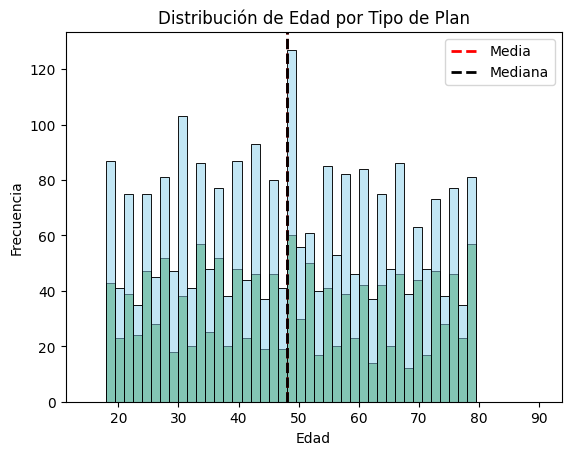

In [36]:
# Histograma para visualizar la edad (age)
mean_age = user_profile['age'].mean()
median_age = user_profile['age'].median()

sns.histplot(
    data=user_profile,
    x='age',
    hue='plan',
    bins=50,
    binrange=(15, 90),
    palette=['skyblue', 'green'],
    edgecolor='black'
)

# Agregar líneas de media y mediana

plt.axvline(mean_age, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(median_age, color='black', linestyle='dashed', linewidth=2, label='Mediana')


# Títulos y etiquetas

plt.title('Distribución de Edad por Tipo de Plan')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

💡Insights: 
- La distribución de edad muestra una media y mediana prácticamente iguales, alrededor de los 48–50 años, lo que indica una población bastante equilibrada y sin sesgos marcados hacia edades jóvenes o mayores. El rango es amplio (aproximadamente de 18 a 80 años), lo que sugiere que el servicio tiene una penetración intergeneracional y no está concentrado en un único segmento etario.

Al comparar por tipo de plan, las distribuciones de Básico y Premium se superponen casi por completo, sin diferencias visuales significativas en dispersión o concentración. Esto indica que la edad no parece ser un factor determinante en la elección del plan, por lo que variables de comportamiento como consumo, frecuencia de uso o nivel de gasto podrían ser más relevantes para explicar la migración hacia planes Premium.

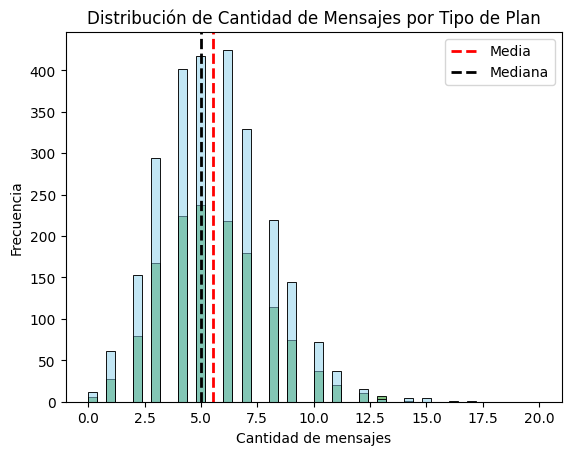

In [37]:
# Histograma para visualizar la cant_mensajes
mean_cant_mensajes = user_profile['cant_mensajes'].mean()
median_cant_mensajes = user_profile['cant_mensajes'].median()

sns.histplot(
    data=user_profile,
    x='cant_mensajes',
    hue='plan',
    bins=50,
    binrange=(0, 20),
    palette=['skyblue', 'green'],
    edgecolor='black'
)

# Agregar líneas de media y mediana

plt.axvline(mean_cant_mensajes, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(median_cant_mensajes, color='black', linestyle='dashed', linewidth=2, label='Mediana')


# Títulos y etiquetas

plt.title('Distribución de Cantidad de Mensajes por Tipo de Plan')
plt.xlabel('Cantidad de mensajes')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

💡Insights: 
- En la distribución de cantidad de mensajes, se observa que tanto los usuarios del plan Básico como del plan Premium concentran su uso principalmente entre 3 y 7 mensajes, lo que indica un comportamiento de mensajería moderado en ambos planes. Sin embargo, el plan Premium presenta una mayor frecuencia en los valores más altos, con una cola más larga hacia la derecha, lo que sugiere que estos usuarios tienden a enviar más mensajes en promedio y con mayor variabilidad. Esto también se refleja en que la media es ligeramente mayor que la mediana, confirmando que la distribución está sesgada a la derecha, impulsada por usuarios intensivos. En contraste, los usuarios del plan Básico muestran una distribución más concentrada alrededor del centro y menos casos extremos, lo que indica un uso más contenido y predecible. En conjunto, el patrón sugiere que el tipo de plan sí influye en el nivel de uso, especialmente en los comportamientos de mayor consumo.

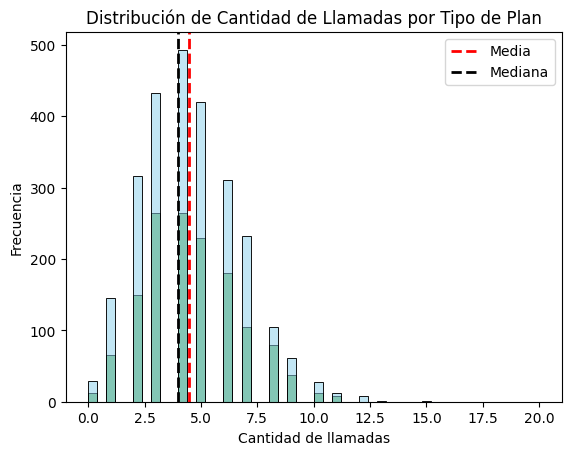

In [38]:
# Histograma para visualizar la cant_llamadas
mean_cant_llamadas = user_profile['cant_llamadas'].mean()
median_cant_llamadas = user_profile['cant_llamadas'].median()

sns.histplot(
    data=user_profile,
    x='cant_llamadas',
    hue='plan',
    bins=50,
    binrange=(0, 20),
    palette=['skyblue', 'green'],
    edgecolor='black'
)

# Agregar líneas de media y mediana

plt.axvline(mean_cant_llamadas, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(median_cant_llamadas, color='black', linestyle='dashed', linewidth=2, label='Mediana')


# Títulos y etiquetas

plt.title('Distribución de Cantidad de Llamadas por Tipo de Plan')
plt.xlabel('Cantidad de llamadas')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()


💡Insights: 
- En la distribución de cantidad de llamadas, se observa que tanto los usuarios del plan Básico como del plan Premium concentran la mayor parte de sus llamadas entre 2 y 6 llamadas, lo que indica un patrón de uso relativamente similar en frecuencia. No obstante, el plan Premium muestra una mayor dispersión y una cola más extensa hacia valores altos, lo que sugiere que existen más usuarios que realizan un número elevado de llamadas. La media se encuentra ligeramente a la derecha de la mediana, confirmando una distribución sesgada a la derecha, impulsada por usuarios con mayor intensidad de uso. En contraste, los usuarios del plan Básico presentan una distribución más compacta y menos valores extremos, lo que refleja un comportamiento más estable y predecible en cuanto a número de llamadas.

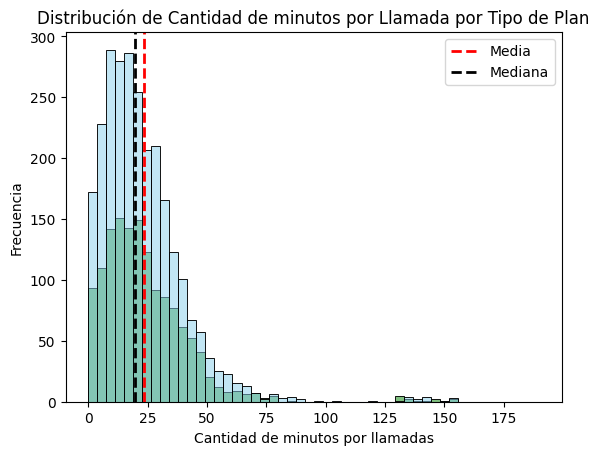

In [39]:
# Histograma para visualizar la cant_minutos_llamada
mean_duration = user_profile['duration'].mean()
median_duration = user_profile['duration'].median()

sns.histplot(
    data=user_profile,
    x='duration',
    hue='plan',
    bins=50,
    binrange=(0, 190),
    palette=['skyblue', 'green'],
    edgecolor='black'
)

# Agregar líneas de media y mediana

plt.axvline(mean_duration, color='red', linestyle='dashed', linewidth=2, label='Media')
plt.axvline(median_duration, color='black', linestyle='dashed', linewidth=2, label='Mediana')


# Títulos y etiquetas

plt.title('Distribución de Cantidad de minutos por Llamada por Tipo de Plan')
plt.xlabel('Cantidad de minutos por llamadas')
plt.ylabel('Frecuencia')
plt.legend()

plt.show()

💡Insights: 
- En la distribución de minutos por llamada, se aprecia una diferencia más marcada entre planes. Los usuarios del plan Premium tienden a concentrarse en duraciones de llamada más largas, con una cola derecha mucho más pronunciada y presencia de valores extremos, lo que indica llamadas significativamente más prolongadas. La media supera claramente a la mediana, evidenciando una distribución fuertemente sesgada a la derecha, típica de variables de consumo donde pocos usuarios generan un uso muy alto. Por su parte, los usuarios del plan Básico se concentran en duraciones cortas y medias, con menor variabilidad. Este patrón sugiere que el tipo de plan influye de manera clara en la intensidad del uso, especialmente en el tiempo total dedicado a llamadas, siendo el plan Premium el que agrupa a los usuarios más intensivos.

### 5.2 Identificación de Outliers

🎯 **Objetivo:**  
Detectar valores extremos en las variables clave de **uso** y **clientes** que podrían afectar el análisis, y decidir si requieren limpieza o revisión adicional.

**Instrucciones:**  
- Usa **boxplots** para identificar visualmente outliers en las siguientes columnas:  
  - `age` 
  - `cant_mensajes`
  - `cant_llamadas`
  - `total_minutos_llamada`  
- Crea un **for** para generar los 4 boxplots automáticamente.
<br>

- Después de crear los gráfico, responde si **existen o no outliers** en las variables.  
- Si hay outliers, crea otro bucle para calcular los límites de esas columnas usando el **método IQR** y decide qué hacer con ellos.
  - Si solamente hay outliers de un solo lado, no es necesario calcular ambos límites.

**Hint:**
- Dentro del bucle, usa `plt.title(f'Boxplot: {col}')` para que el título cambie acorde a la columna.

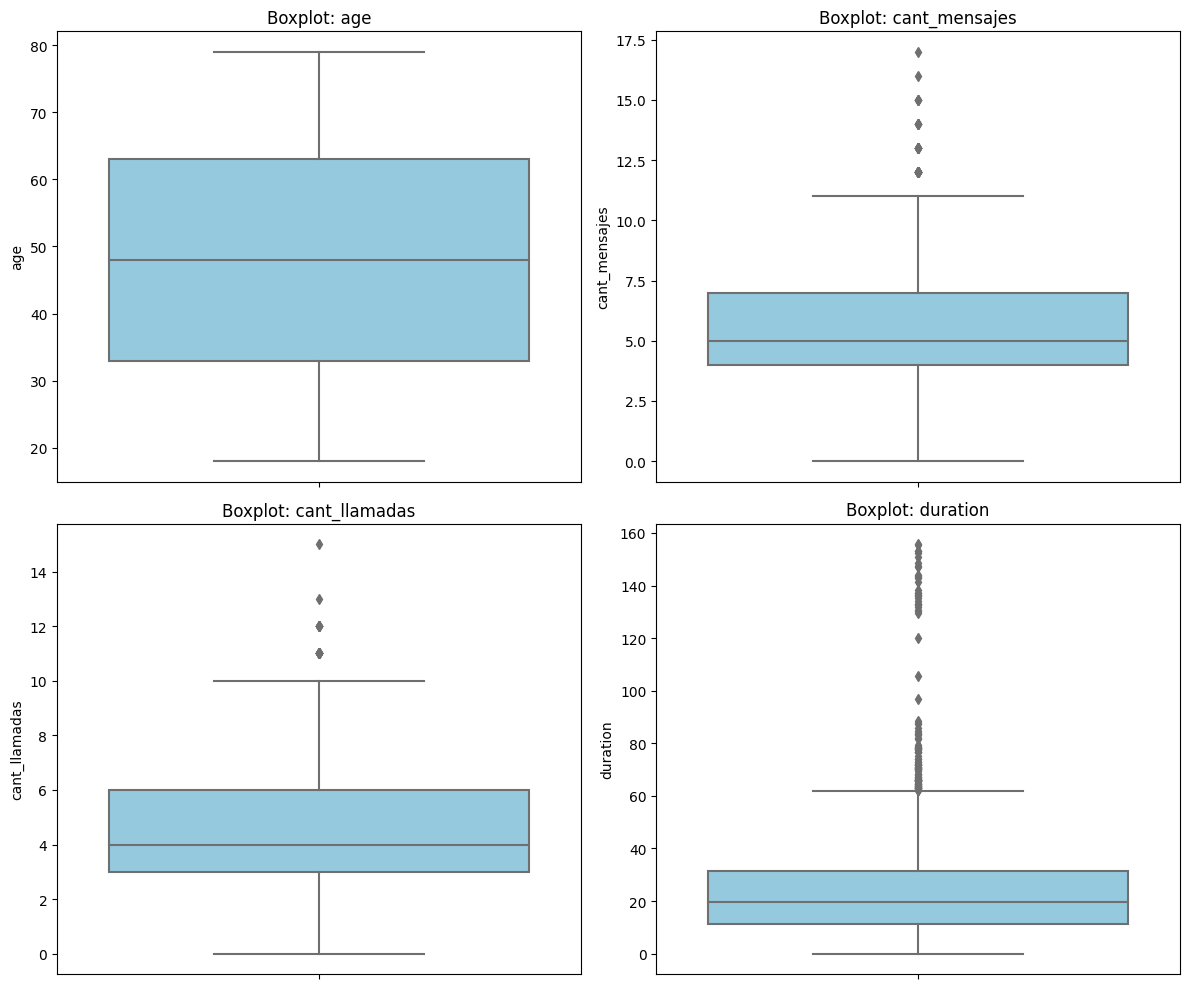

In [40]:
# Visualizando usando BoxPlot 

columnas_numericas = ['age', 'cant_mensajes', 'cant_llamadas', 'duration']

plt.figure(figsize=(12, 10))

for i, col in enumerate(columnas_numericas, 1):
    plt.subplot(2, 2, i)
    sns.boxplot(y=user_profile[col], color='skyblue')
    plt.title(f'Boxplot: {col}')
    plt.ylabel(col)

plt.tight_layout()
plt.show()

💡Insights: 
- Age: El boxplot de edad no presenta outliers visibles, lo que indica que no existen valores extremos atípicos dentro de esta variable. La distribución es relativamente amplia pero balanceada, con una mediana cercana al centro del rango intercuartílico, lo que sugiere una población diversa en edad pero sin registros anómalos. Este comportamiento es consistente con una variable demográfica bien capturada y no requiere ningún tipo de limpieza o tratamiento adicional.
- cant_mensajes:se observan outliers claramente en el extremo superior, correspondientes a usuarios que envían un número significativamente mayor de mensajes que la mayoría. La mediana se encuentra alrededor de los valores centrales, mientras que los valores atípicos indican la presencia de usuarios intensivos. Estos outliers no parecen ser errores, sino comportamientos reales que aportan información relevante sobre patrones de uso, especialmente para análisis de segmentación o consumo.
- cant_llamadas: también muestra outliers únicamente del lado superior, representando usuarios que realizan muchas más llamadas que el promedio. La distribución central es compacta, con una mediana bien definida, lo que indica que la mayoría de los usuarios tiene un comportamiento homogéneo, mientras que unos pocos presentan un uso intensivo. Al igual que en mensajes, estos valores extremos son coherentes con la lógica del negocio y no deberían eliminarse automáticamente.
- cant_minutos_llamada: presenta la mayor cantidad y magnitud de outliers, todos concentrados en el extremo superior. Esto evidencia una distribución fuertemente sesgada a la derecha, donde la mayoría de las llamadas son cortas o moderadas, pero existen usuarios con llamadas extremadamente largas. Estos outliers tienen un alto impacto en métricas como la media y son críticos para entender el consumo real; por lo tanto, deben analizarse con cuidado y tratarse estadísticamente (por ejemplo, usando mediana o percentiles), pero no eliminarse sin un objetivo analítico claro.

In [41]:
# Calcular límites con el método IQR
columnas_limites = ['cant_mensajes', 'cant_llamadas', 'duration']

for col in columnas_limites:
    Q1 = user_profile[col].quantile(0.25)
    Q3 = user_profile[col].quantile(0.75)
    IQR = Q3 - Q1
    
    limite_superior = Q3 + 1.5 * IQR
    
    print(f'\nVariable: {col}')
    print(f'Límite superior: {limite_superior:.2f}')
    print(f'Outliers detectados: {(user_profile[col] > limite_superior).sum()}')




Variable: cant_mensajes
Límite superior: 11.50
Outliers detectados: 46

Variable: cant_llamadas
Límite superior: 10.50
Outliers detectados: 30

Variable: duration
Límite superior: 61.86
Outliers detectados: 109


In [42]:
# Revisa los limites superiores y el max, para tomar la decisión de mantener los outliers o no
user_profile[columnas_limites].describe()

,cant_mensajes,cant_llamadas,duration
count,3999.000000,3999.000000,3999.000000
mean,5.524381,4.478120,23.317054
std,2.358416,2.144238,18.168095
min,0.000000,0.000000,0.000000
25%,4.000000,3.000000,11.120000
50%,5.000000,4.000000,19.780000
75%,7.000000,6.000000,31.415000
max,17.000000,15.000000,155.690000


💡Insights: 
- 
cant_mensajes: mantener o no outliers, porqué?
 

Límite superior (IQR): 11.50
Máximo observado: 17
Outliers detectados: 46 de 3,999 (~1.1%)

El máximo (17) supera el límite superior, pero no de forma extrema. Además, la mediana (5) y el Q3 (7) indican que estos valores representan usuarios que envían 2–3 veces más mensajes que el usuario típico, algo totalmente plausible en un servicio de telecomunicaciones. La cantidad de outliers es baja y no distorsiona significativamente la distribución general.

Decisión:Mantener los outliers.
Representan usuarios intensivos reales y aportan información valiosa sobre patrones de alto consumo. No parecen errores ni valores anómalos artificiales.

- cant_llamadas: mantener o no outliers, porqué?

Límite superior (IQR): 10.50
Máximo observado: 15
Outliers detectados: 30 de 3,999 (~0.75%)


El máximo excede el límite superior de manera moderada. La diferencia entre el Q3 (6) y el máximo (15) sugiere usuarios que hacen más del doble de llamadas que la mayoría, pero sin llegar a valores ilógicos o extremos. La proporción de outliers es aún menor que en mensajes, lo que refuerza que son casos puntuales y coherentes.

Decisión: Mantener los outliers.
Son consistentes con comportamientos reales (por ejemplo, usuarios con alta actividad laboral o comercial) y no comprometen la calidad del análisis.

- cant_minutos_llamada: mantener o no outliers, porqué?

Límite superior (IQR): 61.86
Máximo observado: 155.69
Outliers detectados: 109 de 3,999 (~2.7%)

La diferencia entre el límite superior y el máximo es muy significativa. Mientras que el 75% de los usuarios no supera los 31 minutos, existen llamadas extremadamente largas que empujan fuertemente la media (23.3) por encima de la mediana (19.8). Estos valores tienen un alto impacto estadístico, aunque siguen siendo plausibles desde el negocio (llamadas extensas, soporte, trabajo remoto).

Decisión: Mantener los outliers, pero con tratamiento analítico.
No deben eliminarse por defecto, pero sí: usar mediana y percentiles en lugar de la media y considerar winsorización o segmentación.


---

## 🧩Paso 6: Segmentación de Clientes

### 6.1 Segmentación de Clientes Por Uso

🎯 **Objetivo:** Clasificar a cada usuario en un grupo de uso (Bajo uso, Uso medio, Alto uso) basándose en la cantidad de llamadas y mensajes registrados.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_uso` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones de llamadas y mensajes y asigna:
  - `'Bajo uso'` cuando llamadas < 5 y mensajes < 5
  - `'Uso medio'` cuando llamadas < 10 y mensajes < 10
  - `'Alto uso'` para el resto de casos

In [43]:
# Crear columna grupo_uso
user_profile['grupo_uso'] = np.where(
    (user_profile['cant_llamadas'] < 5) & (user_profile['cant_mensajes'] < 5),
    'Bajo uso',
    np.where(
        (user_profile['cant_llamadas'] < 10) & (user_profile['cant_mensajes'] < 10),
        'Uso medio',
        'Alto uso'
    )
)

In [44]:
# verificar cambios
user_profile.head()

,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,duration,grupo_uso
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso


### 6.2 Segmentación de Clientes Por Edad

🎯 **Objetivo:**: Clasificar a cada usuario en un grupo por **edad**.

**Instrucciones:**  
- Crea una nueva columna llamada `grupo_edad` en el dataframe `user_profile`.
- Usa comparaciones lógicas (<, >) para evaluar las condiciones y asigna:
  - `'Joven'` cuando age < 30
  - `'Adulto'` cuando age < 60
  - `'Adulto Mayor'` para el resto de casos

In [45]:
# Crear columna grupo_edad
user_profile['grupo_edad'] = np.where(
    user_profile['age'] < 30,
    'Joven',
    np.where(
        user_profile['age'] < 60,
        'Adulto',
        'Adulto Mayor'
    )
)

In [46]:


# verificar cambios
user_profile.head()



,user_id,first_name,last_name,age,city,reg_date,plan,churn_date,cant_mensajes,cant_llamadas,duration,grupo_uso,grupo_edad
0,10000,Carlos,Garcia,38.0,Medellín,2022-01-01 00:00:00.000000000,Basico,NaN,7.0,3.0,23.70,Uso medio,Adulto
1,10001,Mateo,Torres,53.0,NaN,2022-01-01 06:34:17.914478619,Basico,NaN,5.0,10.0,33.18,Alto uso,Adulto
2,10002,Sofia,Ramirez,57.0,CDMX,2022-01-01 13:08:35.828957239,Basico,NaN,5.0,2.0,10.74,Uso medio,Adulto
3,10003,Mateo,Ramirez,69.0,Bogotá,2022-01-01 19:42:53.743435858,Premium,NaN,11.0,3.0,8.99,Alto uso,Adulto Mayor
4,10004,Mateo,Torres,63.0,GDL,2022-01-02 02:17:11.657914478,Basico,NaN,4.0,3.0,8.01,Bajo uso,Adulto Mayor


### 6.3 Visualización de la Segmentación de Clientes

🎯 **Objetivo:** Visualizar la distribución de los usuarios según los grupos creados: **grupo_uso** y **grupo_edad**.

**Instrucciones:**  
- Crea dos gráficos para las variables categóricas `grupo_uso` y `grupo_edad`.
- Agrega título y etiquetas a los ejes en cada gráfico.

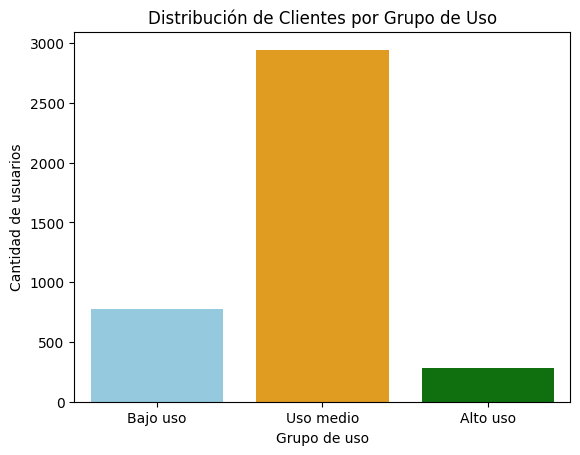

In [47]:
# Visualización de los segmentos por uso
sns.countplot(
    data=user_profile,
    x='grupo_uso',
    order=['Bajo uso', 'Uso medio', 'Alto uso'],
    palette=['skyblue', 'orange', 'green']
)

plt.title('Distribución de Clientes por Grupo de Uso')
plt.xlabel('Grupo de uso')
plt.ylabel('Cantidad de usuarios')
plt.show()

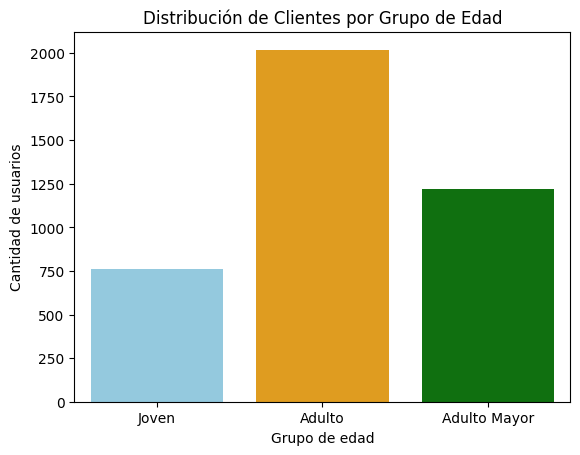

In [48]:
# Visualización de los segmentos por edad
sns.countplot(
    data=user_profile,
    x='grupo_edad',
    order=['Joven', 'Adulto', 'Adulto Mayor'],
    palette=['skyblue', 'orange', 'green']
)

plt.title('Distribución de Clientes por Grupo de Edad')
plt.xlabel('Grupo de edad')
plt.ylabel('Cantidad de usuarios')
plt.show()

In [53]:
user_profile['grupo_uso'].value_counts(normalize=True) * 100
user_profile.groupby('grupo_uso')[['cant_llamadas','cant_mensajes']].mean()

,cant_llamadas,cant_mensajes
grupo_uso,,
Alto uso,5.946043,9.561151
Bajo uso,2.808483,3.132391
Uso medio,4.780836,5.775399


In [54]:
pd.crosstab(user_profile['grupo_edad'], 
            user_profile['grupo_uso'], 
            normalize='index') * 100

grupo_uso,Alto uso,Bajo uso,Uso medio
grupo_edad,,,
Adulto,7.631318,18.037661,74.331021
Adulto Mayor,6.055646,21.031097,72.913257
Joven,6.710526,20.657895,72.631579



---
## 🧩Paso 7: Insight Ejecutivo para Stakeholders

🎯 **Objetivo:** Traducir los hallazgos del análisis en conclusiones accionables para el negocio, enfocadas en segmentación, patrones de uso y oportunidades comerciales.

**Preguntas a responder:** 
- ¿Qué problemas tenían originalmemte los datos?¿Qué porcentaje, o cantidad de filas, de esa columna representaban?
En el dataset users, los principales problemas iniciales fueron valores nulos en las columnas city (11.73%) y churn_date (88.35%). En el caso de city, el porcentaje se encuentra en un rango intermedio (5–30%), lo que implica que no es crítico pero sí puede afectar análisis de segmentación geográfica. No es recomendable eliminar la columna ni los registros; más bien, conviene evaluar imputación o analizar si los usuarios sin ciudad presentan comportamientos distintos. Por otro lado, los nulos en churn_date no representan un error de calidad de datos, sino un valor estructural: indican que el cliente sigue activo. Eliminar estas filas implicaría perder la mayoría de la base (88.35%). La decisión más estratégica es transformar esta variable en un indicador binario de churn (0 = activo, 1 = cancelado), lo que facilita análisis de retención, segmentación por riesgo y diseño de estrategias comerciales enfocadas en reducir cancelaciones.

En el dataset usage, los problemas fueron más marcados en términos estructurales. La columna date presenta solo 0.13% de valores nulos, por lo que su eliminación tiene un impacto mínimo y no compromete el análisis temporal. Sin embargo, duration (55.19%) y length (44.74%) muestran altos porcentajes de nulos. Antes de imputar o eliminar, es clave analizar su relación con la variable type. Es altamente probable que estos sean nulos estructurales: por ejemplo, duration aplicaría únicamente a llamadas y length a mensajes. Si se confirma esta hipótesis, los nulos no representan un problema de calidad sino una característica propia del modelo de negocio (diferentes tipos de consumo). En ese caso, mantenerlos es correcto y permite segmentar patrones de uso por tipo de servicio. Esto abre oportunidades comerciales claras: identificar qué tipo de usuario consume más llamadas vs. mensajes, diseñar planes diferenciados y detectar perfiles con alto riesgo de churn según su patrón de uso.

En conclusión, los principales “problemas” iniciales no fueron necesariamente errores de datos, sino características estructurales que, correctamente interpretadas, se convierten en variables estratégicas para segmentación, análisis de comportamiento y optimización de ofertas comerciales.

- ¿Qué segmentos de clientes identificaste y cómo se comportan según su edad y nivel de uso?

Se identificaron dos dimensiones de segmentación:
Por edad: Joven, Adulto, Adulto Mayor

Por nivel de uso: Bajo uso, Uso medio, Alto uso

Al cruzar ambas variables se observa un patrón muy consistente entre edades.

El análisis permitió identificar tres segmentos etarios y tres niveles de uso. Se observa que aproximadamente el 73–74% de los clientes en todos los grupos de edad se concentran en el segmento de uso medio, lo que indica un patrón de consumo homogéneo entre generaciones. El segmento de alto uso representa menos del 8% en todos los casos, sugiriendo una oportunidad de crecimiento mediante estrategias de fidelización o incremento de consumo. Por su parte, los adultos mayores presentan una ligera mayor proporción en bajo uso, lo que podría abrir oportunidades de personalización de planes básicos o estrategias de retención específicas para este grupo.

Los Adultos Mayores tienen ligeramente más bajo uso, lo que podría indicar menor intensidad de consumo o preferencia por planes más básicos.

- ¿Qué segmentos parecen más valiosos para ConnectaTel y por qué?
El análisis de segmentación indica que los clientes más valiosos para ConnectaTel son aquellos clasificados en el segmento de Alto uso, ya que, aunque representan una proporción menor del total de usuarios (menos del 8% en todos los grupos de edad), son quienes presentan mayor intensidad de consumo y, por lo tanto, mayor potencial de generación de ingresos por usuario. No obstante, el segmento de Uso medio constituye el núcleo del negocio, concentrando alrededor del 73–74% de los clientes en cada grupo etario, lo que lo convierte en el principal sostén de ingresos por volumen y en una oportunidad estratégica para implementar acciones de upselling que incrementen el consumo. Por su parte, el segmento de Bajo uso, aunque menos atractivo en términos de rentabilidad directa, es relevante desde la perspectiva de retención, ya que podría presentar mayor riesgo de cancelación o subutilización del servicio. En conjunto, la estrategia comercial debería enfocarse en fidelizar a los usuarios de alto consumo, potenciar la migración del uso medio hacia niveles superiores y diseñar acciones específicas para reducir el churn en el segmento de bajo uso.

- ¿Qué patrones de uso extremo (outliers) encontraste y qué implican para el negocio?
El análisis de outliers revela un patrón consistente en las tres variables evaluadas (cant_mensajes, cant_llamadas y cant_minutos_llamada): los valores atípicos aparecen exclusivamente en el extremo superior, lo que indica la presencia de usuarios intensivos, no errores de captura.

En cant_mensajes, se detectaron 46 outliers (1.1%), con un máximo de 17 frente a un límite IQR de 11.5. La diferencia no es extrema y refleja usuarios que envían entre 2 y 3 veces más mensajes que el promedio. Esto es completamente coherente con el modelo de negocio de telecomunicaciones. Su baja proporción y su plausibilidad indican que deben mantenerse, ya que representan un segmento real de alto consumo.

En cant_llamadas, se identificaron 30 outliers (0.75%), con un máximo de 15 frente a un límite superior de 10.5. Nuevamente, el comportamiento es consistente: pocos usuarios realizan significativamente más llamadas que el resto, pero dentro de rangos lógicos. Este grupo puede representar perfiles laborales o comerciales con alta actividad. No eliminarlos permite preservar información clave sobre clientes de alto valor.

La variable más relevante es cant_minutos_llamada, donde se encontraron 109 outliers (2.7%), con un máximo de 155.69 frente a un límite IQR de 61.86. Aquí sí se observa una fuerte asimetría positiva: mientras el 75% de los usuarios no supera los 31 minutos, algunos presentan llamadas extremadamente largas. Estos valores elevan la media por encima de la mediana, mostrando su impacto estadístico. Sin embargo, siguen siendo plausibles desde la lógica del negocio (trabajo remoto, soporte técnico, llamadas prolongadas). Por ello, no deben eliminarse, pero sí analizarse cuidadosamente utilizando métricas robustas como mediana y percentiles o técnicas como winsorización si el objetivo es modelado predictivo.

Implicaciones para ConnectaTel

Los outliers representan usuarios intensivos reales, potencialmente los clientes más rentables.

Eliminarlos implicaría perder información estratégica sobre consumo premium.

La distribución sesgada sugiere que el negocio tiene una base homogénea con un pequeño segmento de alto valor.

Las decisiones comerciales deberían considerar segmentar específicamente a estos usuarios de alto consumo para:

Ofrecer planes premium

Programas de fidelización

Estrategias de retención diferenciadas

En conclusión, los patrones extremos no evidencian problemas de calidad de datos, sino la existencia de un segmento intensivo que puede representar una ventaja competitiva si se gestiona estratégicamente.

- ¿Qué recomendaciones harías para mejorar la oferta actual de planes o crear nuevos planes basados en los segmentos y patrones detectados?
El análisis revela que ConnectaTel tiene una base de clientes mayoritariamente concentrada en un segmento de uso medio, con un grupo reducido pero estratégico de usuarios intensivos que generan alto consumo. La presencia de outliers reales confirma que existe una oportunidad clara de segmentación avanzada y diferenciación de planes. La estrategia óptima no es eliminar extremos ni homogenizar la oferta, sino diseñar planes escalonados que respondan al comportamiento real de consumo. Fidelizar al segmento de alto uso, potenciar la migración del uso medio y reducir el riesgo de cancelación en bajo uso permitirá maximizar ingresos, mejorar la retención y fortalecer la competitividad del negocio.


### Análisis ejecutivo

Problemas detectados en los datos

Se identificaron valores nulos relevantes en las bases analizadas. En el dataset de usuarios, la variable city presenta un 11.73% de valores faltantes, lo cual podría afectar análisis de segmentación geográfica y requiere evaluación para posible imputación o análisis diferenciado. Por otro lado, la columna churn_date muestra 88.35% de valores nulos; sin embargo, estos no representan un error, sino que indican clientes activos, por lo que fue más adecuado transformarla en una variable binaria de cancelación.

En el dataset de uso, las variables duration y length presentan altos porcentajes de valores nulos (55.19% y 44.74%, respectivamente), los cuales corresponden a nulos estructurales dependiendo del tipo de consumo (llamadas o mensajes). Asimismo, se detectaron outliers en consumo de mensajes, llamadas y minutos, concentrados únicamente en el extremo superior, los cuales representan comportamientos reales de usuarios intensivos y no errores de captura.


Segmentos por Edad

Se identificaron tres segmentos etarios: Jóvenes, Adultos y Adultos Mayores. El segmento Adulto concentra la mayor proporción de clientes, seguido por Adultos Mayores y finalmente Jóvenes.

El comportamiento entre edades es relativamente homogéneo en términos de nivel de uso, aunque los Adultos Mayores presentan ligeramente mayor proporción de bajo consumo. Esto sugiere que la edad no es un factor determinante en la intensidad de uso, pero sí puede influir marginalmente en patrones de consumo.


Segmentos por Nivel de Uso

Se clasificaron los clientes en tres niveles de uso: Bajo, Medio y Alto. El segmento de Uso Medio concentra aproximadamente el 73–74% de los clientes en todos los grupos etarios, constituyendo el núcleo del negocio.

El segmento de Alto Uso representa menos del 8% de la base, pero muestra patrones de consumo significativamente superiores, incluyendo la presencia de outliers en minutos de llamada. Estos usuarios intensivos, aunque minoritarios, tienen alto potencial de generación de ingresos. El segmento de Bajo Uso, que representa alrededor del 18–21%, podría estar asociado a menor percepción de valor y mayor riesgo de cancelación.


Esto sugiere que ...

El negocio de ConnectaTel se sostiene principalmente en un segmento amplio y estable de usuarios de consumo medio, mientras que existe un grupo reducido pero estratégico de clientes intensivos que probablemente aportan mayor ingreso promedio por usuario (ARPU). La distribución sesgada del consumo indica oportunidades claras para diferenciación de planes y estrategias de monetización escalonada.



Recomendaciones

Se recomienda diseñar una estructura de planes segmentada según comportamiento real de consumo. Para el segmento de Alto Uso, desarrollar planes premium o paquetes ampliados que maximicen ingresos y fortalezcan la fidelización. Para el segmento de Uso Medio, implementar estrategias de upselling que incentiven el incremento gradual del consumo. Finalmente, para el segmento de Bajo Uso, ofrecer planes más flexibles o económicos que reduzcan el riesgo de churn y mejoren la percepción de valor.

En conjunto, la estrategia debe orientarse a fidelizar a los usuarios más rentables, escalar el consumo del segmento medio y optimizar la retención en los segmentos de menor uso, fortaleciendo así la rentabilidad y sostenibilidad del negocio.

---

## 🧩Paso 8 Cargar tu notebook y README a GitHub

🎯 **Objetivo:**  
Entregar tu análisis de forma **profesional**, **documentada** y **versionada**, asegurando que cualquier persona pueda revisar, ejecutar y entender tu trabajo.



### Opción A : Subir archivos desde la interfaz de GitHub (UI)

1. Descarga este notebook (`File → Download .ipynb`).  
2. Entra a tu repositorio en GitHub (por ejemplo `telecom-analysis` o `sprint7-final-project`).  
3. Sube tu notebook **Add file → Upload files**.  

---

### Opción B : Guardar directo desde Google Colab

1. Abre tu notebook en Colab.  
2. Ve a **File → Save a copy in GitHub**.  
3. Selecciona el repositorio y la carpeta correcta (ej: `notebooks/`).  
4. Escribe un mensaje de commit claro, por ejemplo:  
    - `feat: add final ConnectaTel analysis`
    - `agregar version final: Análisis ConnectaTel`
5. Verifica en GitHub que el archivo quedó en el lugar correcto y que el historial de commits se mantenga limpio.

---

Agrega un archivo `README.md` que describa de forma clara:
- el objetivo del proyecto,  
- los datasets utilizados,  
- las etapas del análisis realizadas,  
- cómo ejecutar el notebook (por ejemplo, abrirlo en Google Colab),  
- una breve guía de reproducción.
---

Link a repositorio público del proyecto: `LINK a tu repo aquí`